# Improve the results of quantum phase estimation
**Using Fire Opal's error suppression to enhance the performance of quantum phase estimation on real hardware**

Fire Opal reduces errors and increases algorithmic performance when running quantum algorithms on real quantum hardware.
This is done by optimizing the quantum circuit using techniques from quantum control theory to suppress the noise on NISQ devices and beyond.
Fire Opal applies error suppression and error mitigation across various supported backends without requiring any user configuration—everything happens automatically.

The benefits of Fire Opal are broadly applicable and can be used to improve the performance of any type of quantum algorithm. In this application note, we demonstrate the algorithmic performance improvements of Fire Opal when applied to the quantum algorithm of quantum phase estimation, which is a commonly used subroutine that serves as a building block for various algorithms.

This application note covers the following:
* An introduction to quantum phase estimation and how it is incorporated into quantum simulation algorithms.
* Definition of a simple instance of quantum phase estimation. 
* Execution of the circuits on an ideal simulator and on IBM hardware with and without Fire Opal.
* Analysis of the results and conclusions.

The example in this notebook is inspired by the [Qiskit documentation](https://learn.qiskit.org/course/ch-algorithms/quantum-phase-estimation), and we compare the performance of Fire Opal and IBM default.
***
*Some cells in this notebook require an IBM Quantum account to execute correctly. If you want to run them, please go to the [IBM Quantum portal](https://quantum-computing.ibm.com/login) to set up an account.*
***

## 1. Introduction to quantum phase estimation
In this section, we introduce the problem of quantum phase estimation and explain its relevance in quantum chemistry algorithms.

### 1.1 Definition of the problem of quantum phase estimation

The goal of quantum phase estimation is to provide an estimate on the eigenvalues of a unitary operation $U$.
More specifically, quantum phase estimation is defined by the following task.
For an $n$ qubit unitary $U$, we are given:
1. An $n$ qubit quantum circuit that implements $U$.
    Furthermore, we need to be able to apply controlled $U$ operations,
2. An eigenstate $\vert \varphi \rangle$ of $U$ according to the eigenvalue equation $U \vert \varphi \rangle = e^{2 \pi i \varphi} \vert \varphi \rangle$, and
3. $m$ additional qubits, which we refer to as the "counting qubits".
    
The algorithm of quantum phase estimation then computes the phase $\varphi$ up to an error $\epsilon$ by encoding it into the counting qubit register.
Through this procedure, the error $\epsilon$ becomes exponentially small in the number of counting qubits, $\epsilon = O(1 / 2^m)$.
The quantum circuit of quantum phase estimation looks as follows:

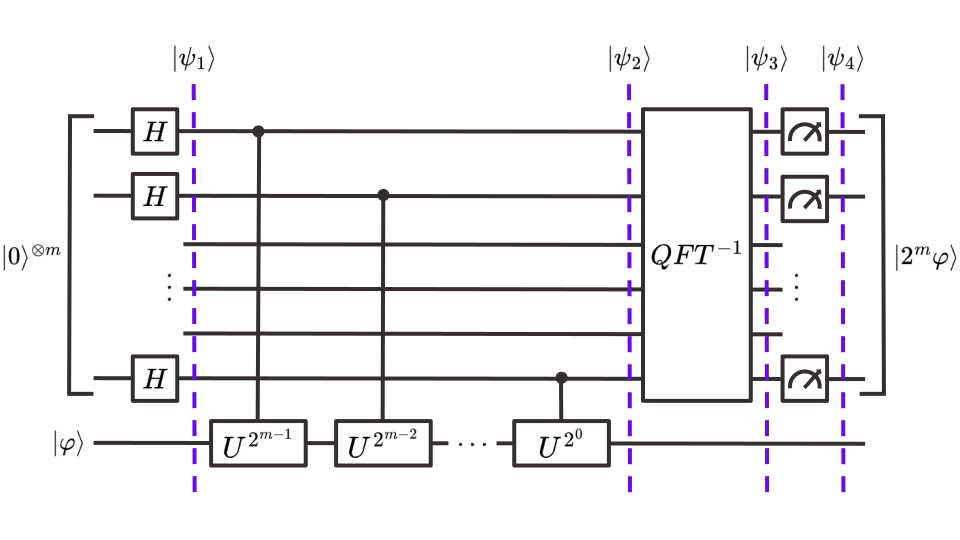

From this circuit, we can see that we need to call the quantum circuit implementing $U$ $O(1 / \epsilon)$ many times.
We will discuss later how to encode the phase $\varphi$ in the final quantum state and how we can retrieve it from measuring the counting qubits.
For the mathematical details on how this quantum circuit works, we refer to the [Qiskit documentation](https://learn.qiskit.org/course/ch-algorithms/quantum-phase-estimation).

If we only have access to an input state $\vert \psi \rangle$, which is not an eigenstate of $U$, we can still perform quantum phase estimation.
In this case, the algorithm projects the input qubits to a specific eigenstate $\vert \varphi_j \rangle$ of $U$ with a probability $p_j = \vert \langle \psi \vert \varphi_j \rangle \vert^2$ and computes the corresponding phase $\varphi_j$.
Therefore, in general quantum phase estimation samples the eigenvalues of $U$ from a probability distribution defined by the input state.
By repeating the algorithm many times, we thus obtain an estimate of all eigenvalues of $U$ with nonzero $p_j$.
Notice that with a large number of repititions it becomes exponentially likely to sample a given eigenvalue at least once.
For example, even for a small overlap of say $p_j = 0.01$, a shot count of $1,000$ suffices to recover $\varphi_j$ with a high probability.

### 1.2 Relevance of quantum phase estimation

Quantum phase estimation is a subroutine in many important quantum algorithms including the simulation of chemical materials such as drugs or fertilizers and Shor's algorithm for RSA decryption.
Here, we focus on its incorporation in quantum chemistry simulation, which is proposed as a promising application of quantum computers.
Using quantum chemistry algorithms, we could potentially find novel medicine or improve the reaction outcomes in industrial production of chemicals.

Many physical properties of chemical materials are derived from the eigenvalues of their corresponding Hamiltonian $H$.
Specifically, the ground state energy (smallest eigenvalue) is an important figure of merit.
By encoding $H$ into a unitary $U$, we can use quantum phase estimation to find its eigenvalues.
There are various ways to perform this encoding, for example:
1. [Hamiltonian simulation](https://learn.microsoft.com/en-us/azure/quantum/user-guide/libraries/chemistry/concepts/algorithms) through Trotterisation,
2. [Linear combination of unitaries](https://arxiv.org/abs/1202.5822), and
3. [Qubitisation](https://pennylane.ai/blog/2021/11/quantum-computing-for-quantum-chemistry-a-brief-perspective/) through a block encoding.

Decoding the results from quantum phase estimation for the corresponding unitary $U$ allows us to conclude what are the eigenvalues of $H$.

### 1.3 Encoding of the eigenvalues

By using phase kickback, quantum phase estimation provides a binary encoding of the phase $\varphi$ in the final state of the counting qubit register.
For example, consider the case of $\varphi = 0.25$ on a quantum computer with $m = 3$ counting qubits.
This quantum computer has $2^m = 2^3 = 8$ different states, which are labeled by all possible 3-digit bitstrings $\vert 000 \rangle, \vert 001 \rangle, \dots,\vert 111 \rangle$.
Each of these bitstrings encodes a number $q$ between $0$ and $7$ – in the exact same way as on a classical computer.
That is, $\vert 000 \rangle \equiv 0, \vert 001 \rangle \equiv 1, \dots$.
Dividing each of these numbers by $8$, that is computing $q / 2^m$, results in numbers between $0$ and $1$, which encode the phase (up to a multiple of $2 \pi$).
In our case, $\varphi = 0.25 = 2 / 8$, and hence we expect to measure the state $\vert 010 \rangle \equiv 2$ after quantum phase estimation.
The above discussion is summarized in the following table:
<a name="quantum_phase_estimation_table"></a>

| Quantum state (bitstring) | Encoded number $q$    | Represented phase $\varphi = q / 2^m$ |
|---    |---    |---    |
| $\vert 000 \rangle$   | $0$   | $0$   |
| $\vert 001 \rangle$ |  $1$    | $0.125$ |
| $\mathbf{\color{#680CE9}{\vert 010 \rangle}}$   | $\mathbf{\color{#680CE9}{2}}$   | $\mathbf{\color{#680CE9}{0.25}}$    |
| $\vert 011 \rangle$   | $3$   | $0.375$   |
| $\vert 100 \rangle$   | $4$   | $0.5$ |
| $\vert 101 \rangle$   | $5$   | $0.625$   |
| $\vert 110 \rangle$   | $6$   | $0.75$    |
| $\vert 111 \rangle$   | $7$   | $0.875$   |

But what happens if the actual phase was not an inverse multiple of $8$?
For instance, imagine a scenario where $\varphi = 0.3$.
In this case, there is no $q / 2^m$, which represents $\varphi$ exactly.
However, we can still perform quantum phase estimation to obtain an estimate of the phase.
The phase $\varphi = 0.3$ lies between $0.25$ and $0.375$ but is closer to $0.25$.
For this reason, after performing the quantum phase estimation algorithm, we will obtain a quantum state which has its maximum probability amplitude in $\vert 010 \rangle$ encoding a phase of $0.25$.
Nevertheless, as opposed to the previous example of $\varphi = 0.25$, we also receive a nonzero probability amplitude in other quantum states.
In general, quantum phase estimation will give us an estimate for the actual phase by providing a lower and upper bound:
One bound is always given by the highest amplitude bitstring.
The other bound is given by the higher amplitude state next to it.
In the case of $\varphi = 0.3$, the two bitstrings next to the highest amplitude one are given by the state $\vert 001 \rangle \equiv 0.125$ (left) and $\vert 011 \rangle \equiv 0.375$ (right).
Thus, we will see that the state $\vert 011 \rangle$ has a higher amplitude than the state $\vert 001 \rangle$ as the desired phase is between $0.25$ and $0.375$.
If we want to increase the accuracy of the estimate, we have to increase the number of counting qubits $m$.
See the following figures for an illustration of the ideal probability distributions:

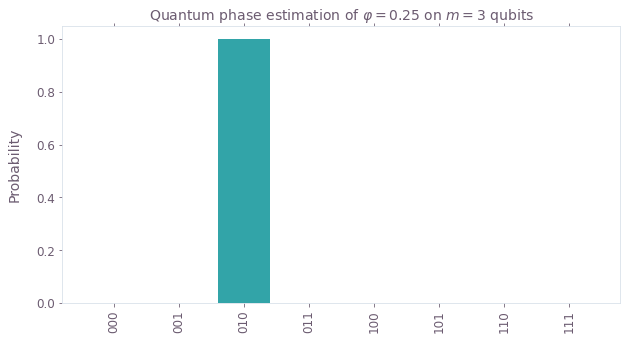

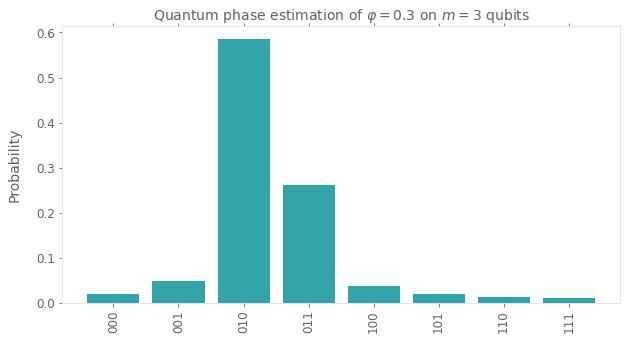

## 2. Imports and initialization
The following section sets up the necessary imports and helper functions, which will be used in creating and evaluating the circuits.

In [4]:
# Import packages.
import math
import fireopal as fo
import numpy as np
import matplotlib.pyplot as plt
import json
import qiskit
from qiskit import qasm2
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import qctrlvisualizer as qv

plt.style.use(qv.get_qctrl_style())

In [38]:
# Define the functions to create the quantum phase estimation circuits.
def power_of_two_q(number):
    """
    Ask whether a number is a power of 2.
    """
    return math.ceil(np.log2(number)) == math.floor(np.log2(number))


def inverse_quantum_fourier_transform(quantum_circuit, number_of_qubits):
    """
    Apply an inverse Quantum Fourier Transform the first `number_of_qubits` qubits in the
    `quantum_circuit`.
    """
    for qubit in range(number_of_qubits // 2):
        quantum_circuit.swap(qubit, number_of_qubits - qubit - 1)
    for j in range(number_of_qubits):
        for m in range(j):
            quantum_circuit.cp(-math.pi / float(2 ** (j - m)), m, j)
        quantum_circuit.h(j)


def create_circuit(number_of_counting_qubits, phase):
    """
    Create a quantum circuit for quantum phase estimation. The unitary, whose phase is evaluated
    is a single qubit phase gate. Its phase can be specified by the input parameter `phase`.
    """
    # Initialize the quantum circuit.
    quantum_circuit = qiskit.QuantumCircuit(
        number_of_counting_qubits + 1, number_of_counting_qubits
    )
    quantum_circuit.x(number_of_counting_qubits)
    for qubit in range(number_of_counting_qubits):
        quantum_circuit.h(qubit)

    # Add the controlled phase gates to the circuit.
    repetitions = 1
    for counting_qubit in range(number_of_counting_qubits):
        for _ in range(repetitions):
            quantum_circuit.cp(phase, counting_qubit, number_of_counting_qubits)
        repetitions *= 2

    quantum_circuit.barrier()

    # Apply the inverse Quantum Fourier Transform.
    inverse_quantum_fourier_transform(quantum_circuit, number_of_counting_qubits)

    # Measure the ancilla register.
    quantum_circuit.barrier()
    for qubit in range(number_of_counting_qubits):
        quantum_circuit.measure(qubit, qubit)

    return quantum_circuit


def bitstring_count_to_probabilities(data, shot_count, number_of_counting_qubits):
    """
    Manipulate the measured and simulated results.
    This function turns an unsorted dictionary of bitstring counts into a sorted dictionary
    of probabilities. It also turns bitstrings from base 0 to base 2 and adds bitstrings,
    with zero count that do not appear in the original dictionary.
    """
    # Check if the base of the bitstrings is 0 and turn it into base 2 in this case.
    if any("x" in key for key in data.keys()):
        base = 0
    else:
        base = 2

    # Turn the bitstring counts into probabilities.
    probabilities = {
        format(int(bitstring, base), f"0{number_of_counting_qubits}b"): bitstring_count
        / shot_count
        for bitstring, bitstring_count in data.items()
    }

    # Add bitstrings with zero count that do not appear in the dictionary.
    padded_probabilities = pad_missing_values(
        probabilities, number_of_counting_qubits=number_of_counting_qubits
    )

    # Sort the dictionary.
    sorted_probabilities = dict(sorted(padded_probabilities.items()))

    return sorted_probabilities


def reformat_dists_results(
    dists, number_of_counting_qubits, experiments_per_phase, phases
):
    """
    Reformats list of quasi-probability distributions to an array of binary probabilities.
    """
    binary_dists = []
    for experiment in dists:
        # Pad missing results.
        padded = pad_missing_values(experiment, number_of_counting_qubits)
        binary_dists.append(padded)

    # Create an array with split up experiment data.
    binary_dists_arr = np.array(binary_dists)
    split_dists = np.split(
        binary_dists_arr[0 : experiments_per_phase * len(phases)], experiments_per_phase
    )
    return split_dists


def pad_missing_values(data, number_of_counting_qubits):
    """
    Add bitstrings with zero count that do not appear in the dictionary.
    """
    all_bitstrings = [
        format(i, f"0{number_of_counting_qubits}b")
        for i in range(2**number_of_counting_qubits)
    ]
    data_with_missing_values = {
        bitstring: data.get(bitstring, 0.0) for bitstring in all_bitstrings
    }
    return data_with_missing_values

## 3. Setting up the problem
The following section involves the problem setup and creation of our circuits.

### 3.1 Setting up our IBM account
We will need to set up our IBM account credentials and session in order to run our circuits on real hardware.

In [ ]:
# Set credentials
token = "YOUR_IBM_CLOUD_API_KEY"
instance = "YOUR_IBM_CRN"

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

service = QiskitRuntimeService(
    token=token, instance=instance, channel="ibm_quantum_platform"
)

### 3.2 Creating the circuits

Here, we choose 10 different phases and run the circuit for each phase twice.
In this way, we obtain 20 data points per number of counting qubits.
We exclude phases that are an inverse power of two to avoid exact results.
This is a more realistic scenario closer to a real quantum chemistry application.

In [11]:
# Set parameters.
shot_count = 4096
phases = [1 / number for number in np.arange(1, 15) if power_of_two_q(number) is False]
experiments_per_phase = 2

# 5 counting qubits.
circuits_quantum_phase_estimation_5 = [
    create_circuit(5, phase) for phase in phases
] * experiments_per_phase
print(
    "quantum phase estimation circuit with m=5 counting qubits and a phase of 𝜑=0.2/2π:"
)
display(circuits_quantum_phase_estimation_5[1].draw(fold=-1))

# 6 counting qubits.
circuits_quantum_phase_estimation_6 = [
    create_circuit(6, phase) for phase in phases
] * experiments_per_phase
print(
    "quantum phase estimation circuit with m=6 counting qubits and a phase of 𝜑=0.2/2π:"
)
display(circuits_quantum_phase_estimation_6[1].draw(fold=-1))

quantum phase estimation circuit with m=5 counting qubits and a phase of 𝜑=0.2/2π:


┌───┐                                                                                                                                                                                                                                                                                        ░    ┌───┐                                                                                                                          ░ ┌─┐            
q_0: ┤ H ├─■──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──X─┤ H ├─■──────────────■───────────────────■────────────────────────■────────────────────────────────────────────────────────────░─┤M├────────────
     ├───┤ │                                                                                                                                                                                                                                                                                      ░  │ └───┘ │P(-π/2) ┌───┐ │                   │                        │                                                            ░ └╥┘┌─┐         
q_1: ┤ H ├─┼────────■────────■────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──┼───X───■────────┤ H ├─┼─────────■─────────┼──────────────■─────────┼────────────────────■───────────────────────────────────────░──╫─┤M├─────────
     ├───┤ │        │        │                                                                                                                                                                                                                                                                    ░  │   │            └───┘ │P(-π/4)  │P(-π/2)  │        ┌───┐ │         │                    │                                       ░  ║ └╥┘┌─┐      
q_2: ┤ H ├─┼────────┼────────┼────────■────────■────────■────────■────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──┼───┼──────────────────■─────────■─────────┼────────┤ H ├─┼─────────┼──────────■─────────┼──────────────■────────────────────────░──╫──╫─┤M├──────
     ├───┤ │        │        │        │        │        │        │                                                                                                                                                                                                                                ░  │   │                                      │P(-π/8) └───┘ │P(-π/4)  │          │P(-π/2)  │        ┌───┐ │                        ░  ║  ║ └╥┘┌─┐   
q_3: ┤ H ├─┼────────┼────────┼────────┼────────┼────────┼────────┼────────■────────■────────■────────■────────■────────■────────■────────■────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──┼───X──────────────────────────────────────■──────────────■─────────┼──────────■─────────┼────────┤ H ├─┼─────────■──────────────░──╫──╫──╫─┤M├───
     ├───┤ │        │        │        │        │        │        │        │        │        │        │        │        │        │        │                                                                                                                                                        ░  │                                                                   │P(-π/16)            │P(-π/8) └───┘ │P(-π/4)  │P(-π/2) ┌───┐ ░  ║  ║  ║ └╥┘┌─┐
q_4: ┤ H ├─┼────────┼────────┼────────┼──────

quantum phase estimation circuit with m=6 counting qubits and a phase of 𝜑=0.2/2π:


┌───┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        ░    ┌───┐                                                                                                                                                                                   ░ ┌─┐               
q_0: ┤ H ├─■──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──X─┤ H ├─■──────────────■───────────────────■────────────────────────■──────────────────────────────■──────────────────────────────────────────────────────────────────────────────────────░─┤M├───────────────
     ├───┤ │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      ░  │ └───┘ │P(-π/2) ┌───┐ │                   │                        │                              │                                                                                      ░ └╥┘┌─┐            
q_1: ┤ H ├─┼────────■────────■────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──┼───X───■────────┤ H ├─┼─────────■─────────┼──────────────■─────────┼────────────────────■─────────┼─────────────────────────■────────────────────────────────────────────────────────────░──╫─┤M├────────────
     ├───┤ │        │        │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    ░  │   │            └───┘ │P(-π/4)  │P(-π/2)  │        ┌───┐ │         │                    │         │                         │                                                            ░  ║ └╥┘┌─┐         
q_2: ┤ H ├─┼────────┼────────┼────────■────────■────────■────────

## 4. Running the algorithm

In this section, we run the results on an ideal simulator and on real hardware both with and without Fire Opal for comparison.

### 4.1 Running on an ideal simulator

In order to assess the quality of the measured results, first run the quantum circuits on an ideal, noiseless simulator. This will serve as our benchmark for comparison.

Transpile the circuits to match the simulator's topology.

In [12]:
# Run the algorithm on the IBM Aer simulator.
aer_simulator = AerSimulator(method="statevector")

# Transpile the circuits for the simulator.
transpiled_circuits_5 = qiskit.transpile(
    circuits_quantum_phase_estimation_5, aer_simulator
)
transpiled_circuits_6 = qiskit.transpile(
    circuits_quantum_phase_estimation_6, aer_simulator
)

In [13]:
# Run the transpiled circuits with the simulator.
simulated_result_5 = (
    aer_simulator.run(transpiled_circuits_5, shots=shot_count).result().get_counts()
)
simulated_result_6 = (
    aer_simulator.run(transpiled_circuits_6, shots=shot_count).result().get_counts()
)

Use the helper function to reformat the simulator results to probabilities to match the other outputs generated by the real hardware runs.

In [14]:
# Turn bitstring counts into probabilities.
simulated_result_5 = [
    bitstring_count_to_probabilities(result, shot_count, 5)
    for result in simulated_result_5
]
simulated_result_6 = [
    bitstring_count_to_probabilities(result, shot_count, 6)
    for result in simulated_result_6
]

### 4.2 Running the algorithm on quantum hardware without Fire Opal

Run the quantum circuits for quantum phase estimation on a real IBM device both with and without Fire Opal.
Note that there might be delays in obtaining the results due to IBM device queues.
If you do not want to wait for the circuits to be executed, you can import data we collected previously by skipping this and the next subsection and proceed to the section afterwards.

To run the circuits using IBM's Qiskit Runtime primitives, the circuits must first be transpiled using a pass manager. However, when using Fire Opal, abstract circuits are still supported.

In [ ]:
# Replace "desired_backend" with the name of the device you wish to use.
# Run fo.show_supported_devices(credentials) to get a list of suppported backend names.
backend_name = "desired_backend"

# Get the backend object to generate a preset staged pass manager.
ibm_backend = service.backend(backend_name, instance=instance)
pm = generate_preset_pass_manager(backend=ibm_backend, optimization_level=3)

# Transpile all circuits.
isa_circuits_5 = pm.run(circuits_quantum_phase_estimation_5)
isa_circuits_6 = pm.run(circuits_quantum_phase_estimation_6)

In [ ]:
# Run the algorithm with IBM default.
sampler = Sampler(ibm_backend)

# Run all circuits using Qiskit Runtime.
ibm_default_job_5 = sampler.run(isa_circuits_5, shots=shot_count)
ibm_default_job_6 = sampler.run(isa_circuits_6, shots=shot_count)

In [43]:
# Retrieve results.
ibm_default_result_5 = ibm_default_job_5.result()
ibm_default_result_6 = ibm_default_job_6.result()

ibm_default_probabilities_5, ibm_default_probabilities_6 = [], []

# Get counts from pubs and transform to bitstrings
for idx, pub_result in enumerate(ibm_default_result_5):
    ibm_default_probabilities_5.append(
        bitstring_count_to_probabilities(
            pub_result.data.c.get_counts(),
            shot_count=shot_count,
            number_of_counting_qubits=5,
        )
    )
for idx, pub_result in enumerate(ibm_default_result_6):
    ibm_default_probabilities_6.append(
        bitstring_count_to_probabilities(
            pub_result.data.c.get_counts(),
            shot_count=shot_count,
            number_of_counting_qubits=6,
        )
    )

### 4.3 Running the algorithm on quantum hardware with Fire Opal
Next, run the circuits with Fire Opal's error suppression pipeline. Fire Opal accepts and works best with abstract circuits.

Again, it's worth noting that there will be delays in receiving results due to IBM queue times. To see where you are in the queue, you can go to https://quantum.ibm.com/jobs.

In [18]:
# Run the circuits with Fire Opal
fire_opal_job_5 = fo.execute(
    circuits=[qasm2.dumps(circuit) for circuit in circuits_quantum_phase_estimation_5],
    shot_count=shot_count,
    credentials=credentials,
    backend_name=backend_name,
)
fire_opal_job_6 = fo.execute(
    circuits=[qasm2.dumps(circuit) for circuit in circuits_quantum_phase_estimation_6],
    shot_count=shot_count,
    credentials=credentials,
    backend_name=backend_name,
)

In [ ]:
# Retrieve the Fire Opal job results
fire_opal_result_5 = fire_opal_job_5.result()["results"]
fire_opal_result_6 = fire_opal_job_6.result()["results"]

## 5. Reformat the results to analyze and display

In [45]:
# Reformat the distributions to binary keys and split up the experiments.
fire_opal_split_exp_5 = reformat_dists_results(
    fire_opal_result_5,
    number_of_counting_qubits=5,
    experiments_per_phase=experiments_per_phase,
    phases=phases,
)
fire_opal_split_exp_6 = reformat_dists_results(
    fire_opal_result_6,
    number_of_counting_qubits=6,
    experiments_per_phase=experiments_per_phase,
    phases=phases,
)

default_split_exp_5 = reformat_dists_results(
    ibm_default_probabilities_5,
    number_of_counting_qubits=5,
    experiments_per_phase=experiments_per_phase,
    phases=phases,
)
default_split_exp_6 = reformat_dists_results(
    ibm_default_probabilities_6,
    number_of_counting_qubits=6,
    experiments_per_phase=experiments_per_phase,
    phases=phases,
)

In [46]:
# Combine datasets.
data_5 = {
    "simulation": simulated_result_5,
    "default": default_split_exp_5,
    "fire_opal": fire_opal_split_exp_5,
}

data_6 = {
    "simulation": simulated_result_6,
    "default": default_split_exp_6,
    "fire_opal": fire_opal_split_exp_6,
}

## 6. Analyzing the data
Analyze the data obtained across all three sets of experiments and compare the outcomes. 

### 6.1 Define plotting functions 

In [52]:
# Define the functions to plot the distributions.
def highest_count_bitstring(data):
    """
    Return the bitstring with the highest count for the measurement results of a single shot.
    """
    return max(data, key=data.get)


def counting_qubits(data):
    """
    Check whether all passed dictionaries with single shot measurements belong to the same
    number of counting qubits and return this number.
    """
    first_keys = iter(list(result.keys())[0] for result in data.values())
    number_of_counting_qubits = len(next(first_keys))

    if not all(len(key) == number_of_counting_qubits for key in first_keys):
        raise ValueError(
            "The input data must contain dictionaries corresponding to the same number of counting qubits."
        )

    return number_of_counting_qubits


def plot_distributions(data, phase_index, number_of_counting_qubits):
    """
    Plot the distributions of all single shot measurements for all three experiments
    "simulation", "default" and "ibm" in one plot.
    """
    # number_of_counting_qubits = counting_qubits(data)
    phase = f"1/{int(1/phases[phase_index])}"

    simulation = data["simulation"]
    default = data["default"]
    fire_opal = data["fire_opal"]

    correct_result = highest_count_bitstring(simulation)

    max_probability = max(
        max(simulation.values()), max(default.values()), max(fire_opal.values())
    )

    figure, axes = plt.subplots(3, 1, layout="constrained")

    # Ideal simulation
    bars_simulation = axes[0].bar(
        list(simulation.keys()),
        list(simulation.values()),
        color=qv.QCTRL_STYLE_COLORS[5],
    )
    axes[0].set_title("Ideal simulation")
    bars_simulation[list(simulation.keys()).index(correct_result)].set_color(
        qv.QCTRL_STYLE_COLORS[2]
    )

    # Default
    bars_default = axes[1].bar(
        list(default.keys()), list(default.values()), color=qv.QCTRL_STYLE_COLORS[1]
    )
    axes[1].set_title("Default")
    bars_default[list(default.keys()).index(correct_result)].set_color(
        qv.QCTRL_STYLE_COLORS[1]
    )

    # Q-CTRL
    bars_fire_opal = axes[2].bar(
        list(fire_opal.keys()), list(fire_opal.values()), color=qv.QCTRL_STYLE_COLORS[0]
    )
    axes[2].set_title("Q-CTRL")
    bars_fire_opal[list(fire_opal.keys()).index(correct_result)].set_color(
        qv.QCTRL_STYLE_COLORS[0]
    )

    for axis in axes.flat:
        axis.set(xlabel="Bitstrings", ylabel="Probabilities")
        axis.set_ylim([0, 1.05 * max_probability])
        axis.tick_params(axis="x", labelrotation=90)

    # Hide labels and tick labels for inner plots.
    for axis in axes.flat:
        axis.label_outer()

    figure.suptitle(
        rf"{number_of_counting_qubits} counting qubits, $2 \pi \varphi$={phase}"
    )
    figure.set_size_inches(20, 10)

    plt.show()

### 6.2 Plot the distributions to compare the ideal, default, and Fire Opal results

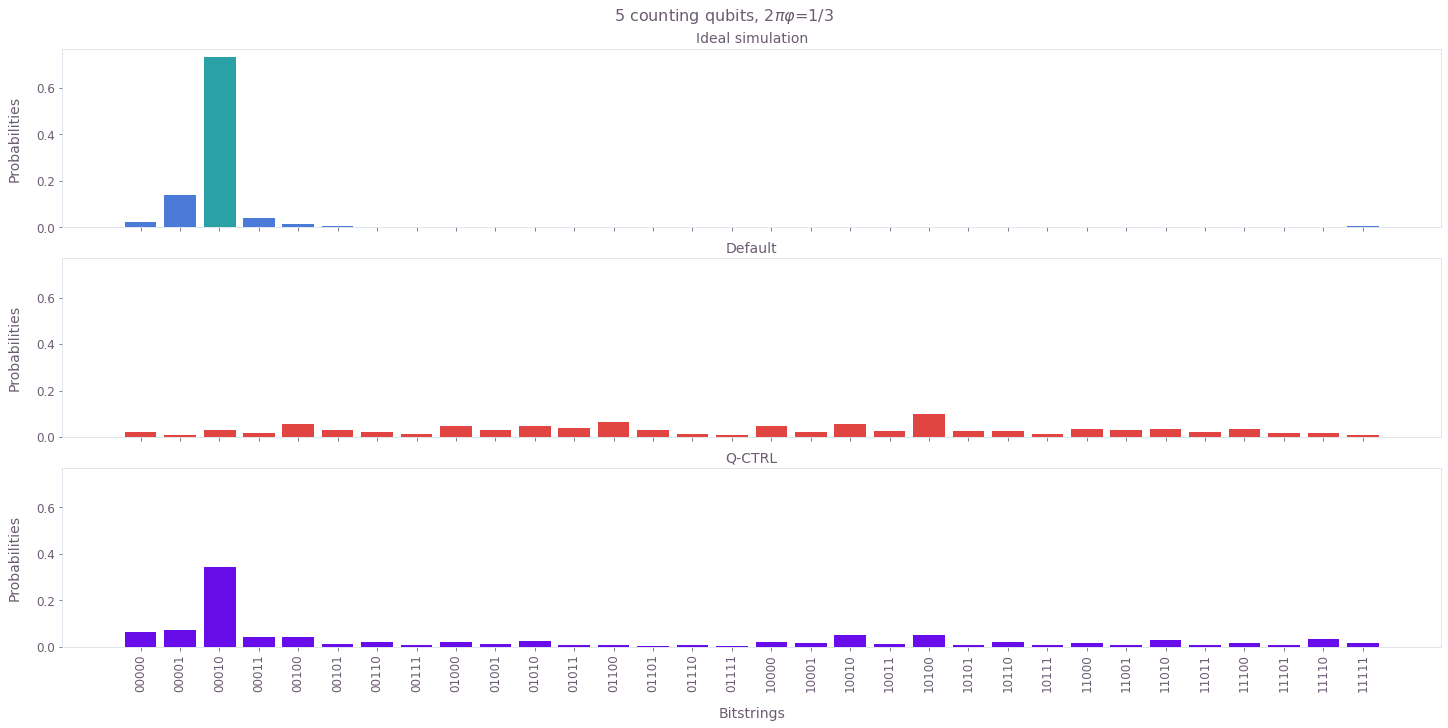

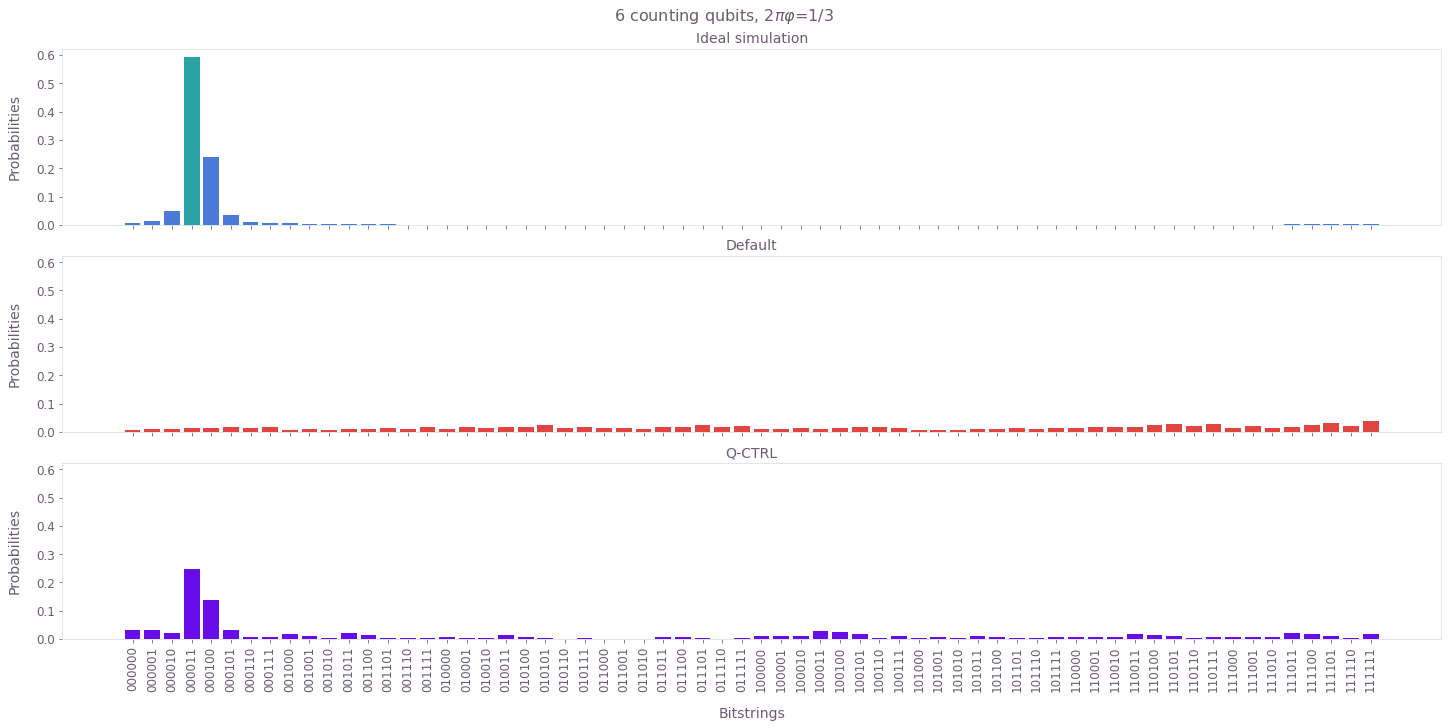

In [53]:
# Specify, which of the data sets to plot by specifying the index of the
# experiment (that is, run 0 or run 1) and the index of the phase in the list
# `phases`. Remember that the experiment was performed twice for each phase,
# so the `experiment_index` specifies, which run is plotted.
experiment_index = 0
phase_index = 0

# Plot the distributions for 5 counting qubits.
distributions_5 = {
    "simulation": data_5["simulation"][phase_index],
    "default": data_5["default"][experiment_index][phase_index],
    "fire_opal": data_5["fire_opal"][experiment_index][phase_index],
}
plot_distributions(distributions_5, phase_index, 5)

# Plot the distributions for 6 counting qubits.
distributions_6 = {
    "simulation": data_6["simulation"][phase_index],
    "default": data_6["default"][experiment_index][phase_index],
    "fire_opal": data_6["fire_opal"][experiment_index][phase_index],
}

plot_distributions(distributions_6, phase_index, 6)

As you can see, the results obtained without Fire Opal are very different to the ideal, correct distribution.
Due to high noise, the qubits get corrupted while the quantum phase estimation circuit is running.
This leads to measurement distributions, which look pretty much random and meaningless.
On the contrary, Fire Opal produces the correct results and the measurement distributions look very similar to the ideal ones.
This observation is independent of the number of counting qubits.
Even for $m = 6$ counting qubits, Fire Opal recovers the same phase as the ideal simulation.
Due to a decent number of counting qubits, we obtain a good estimate for the phase in this case.
The actual phase here is $\varphi = \frac{1}{6 \pi} \approx 0.0531$.
Fire Opal predicts a phase between $3 / 2^6 \approx 0.0469$ and $4 / 2^6 = 0.0625$, but closer to $0.0469$, which is a reasonable approximation.
Furthermore, due to its scalability Fire Opal allows for obtaining even more accurate estimates by increasing the number of counting qubits.

Let's examine the success rates, that is how often we predict the correct highest count bitstring.

In [58]:
def success_rate(data):
    """
    Compare the highest count bitstring of the ideal simulation with the ones obtained
    from the measurements. Return the percentage of correct predictions.
    """
    simulation = data["simulation"]
    ibm_default = data["default"]
    fire_opal = data["fire_opal"]

    simulation_results = [highest_count_bitstring(ideal) for ideal in simulation]

    ibm_default_results = [
        highest_count_bitstring(result) for results in ibm_default for result in results
    ]

    fire_opal_results = [
        highest_count_bitstring(result) for results in fire_opal for result in results
    ]

    correct_results_ibm_default = 0
    correct_results_fire_opal = 0

    for phase_index, correct_result in enumerate(simulation_results):
        if ibm_default_results[phase_index] == correct_result:
            correct_results_ibm_default += 1
        if fire_opal_results[phase_index] == correct_result:
            correct_results_fire_opal += 1

    return (
        100 * correct_results_ibm_default / len(ibm_default_results),
        100 * correct_results_fire_opal / len(fire_opal_results),
    )


def plot_success_rates(data):
    """
    Plot the success rates of a Fire Opal experiment and an IBM default experiment for a different number
    of counting qubits.
    """
    ibm_default, fire_opal = zip(*data.values())

    bar_width = 0.3

    x_ticks = np.array(list(data.keys()))
    plt.xticks(ticks=x_ticks)

    # Fire Opal.
    plt.bar(
        x_ticks - bar_width / 2,
        fire_opal,
        color=qv.QCTRL_STYLE_COLORS[0],
        width=bar_width,
        label="Fire Opal",
    )

    # IBM default.
    plt.bar(
        x_ticks + bar_width / 2,
        ibm_default,
        color=qv.QCTRL_STYLE_COLORS[1],
        width=bar_width,
        label="IBM default",
    )

    plt.title("Highest Count Success Rates")
    plt.xlabel(r"Number of counting qubits $m$")
    plt.ylabel("Success rate in %")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

    plt.show()

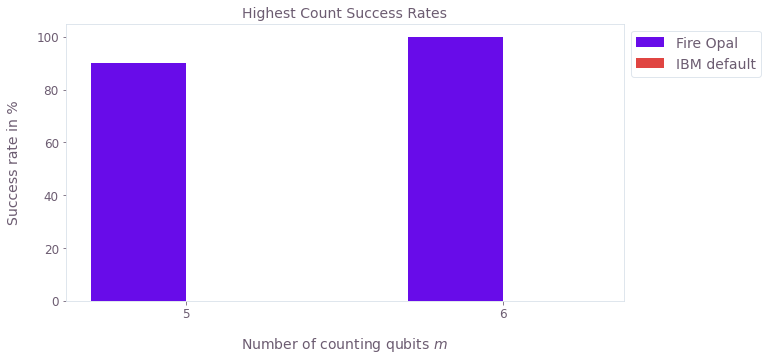

In [59]:
success_rates = {5: success_rate(data_5), 6: success_rate(data_6)}

plot_success_rates(data=success_rates)

As you can see, Fire Opal consistently predicts the correct answer even as the number of counting qubits increases. Without Fire Opal, the default hardware never produced a single distribution within 20 runs that yielded the correct result as the highest probability bitstring.

## 7. Conclusion

We performed quantum phase estimation for 10 different phases and repeated each experiment twice.
In this way, we obtained 20 data points to average over in order to compute the success rates.
From the plot, we can see that the IBM default configuration generally does not recover the correct bitstring as its highest count.
In the case of five or six counting qubits, the success rate is even zero, that is all predictions are wrong.
On the other hand, Fire Opal achieves a success rate over 90% in both cases of 5 and 6 counting qubits.

Fire Opal allows you to get correct answers from quantum phase estimation without additional overhead, whereas running on the default hardware typically results in pure noise.
By allowing you to scale to higher numbers of counting qubits without any performance degradation, Fire Opal provides better accuracy for the estimated phase.
This example shows how Fire Opal is an excellent tool for near term quantum chemistry applications, just as it can be applied to other algorithms to similarly improve the likelihood of achieving quality results.

The package versions below were used to produce this notebook.

In [1]:
from fireopal import print_package_versions

print_package_versions()

| Package               | Version |
| --------------------- | ------- |
| Python                | 3.11.8  |
| networkx              | 2.8.8   |
| numpy                 | 1.26.4  |
| sympy                 | 1.12    |
| fire-opal             | 7.3.1   |
| qctrl-workflow-client | 3.0.0   |
